# 🎲 Week 2 — Day 2: Probability & Distributions

**BinX Tech — AI & Machine Learning Internship Program**

![status](https://img.shields.io/badge/status-in--progress-yellow)
![python](https://img.shields.io/badge/python-3.10%2B-blue)
![libraries](https://img.shields.io/badge/libraries-NumPy%20%7C%20Matplotlib-orange)

---

| | |
|---|---|
| **Day** | Day 2 of 5 |
| **Duration** | 8 hours |
| **Tools** | NumPy • Matplotlib • Jupyter Notebook |
| **Prerequisite** | Day 1 completed |

---

## 🎯 Learning Objectives

- Apply the complement, addition, and multiplication rules of probability.
- Explain conditional probability and Bayes' theorem and where they appear in ML.
- Recognize the normal, binomial, and uniform distributions.

---

## 📖 Step 1 — Probability Basics

Probability quantifies uncertainty — and ML models fundamentally output probabilities
(e.g. "85% likely to churn"). A probability is a number from 0 (impossible) to 1 (certain).

---

## 📐 Step 2 — Core Rules of Probability

| Rule | Statement | Meaning |
|---|---|---|
| **Complement** | P(not A) = 1 − P(A) | The chance something does NOT happen |
| **Addition** | P(A or B) = P(A) + P(B) − P(A and B) | The chance of either event |
| **Multiplication (independent)** | P(A and B) = P(A) × P(B) | Both happen, when unrelated |

### 🧪 Hands-On: Simulating a Coin Flip

n_flips = 10000
flips = np.random.choice(["Heads", "Tails"], size=n_flips)

prop_heads = np.mean(flips == "Heads")
print(f"Proportion of Heads after {n_flips} flips: {prop_heads:.4f}")
print("Expected (theoretical) probability: 0.5000")

### 📝 Interpretation


- How close is the simulated proportion to the theoretical 0.5?
- What would happen to this gap if `n_flips` were much smaller (e.g. 10)? Try it and compare.

---


## 🔗 Step 3 — Conditional Probability

Conditional probability, written **P(A | B)**, is the probability of A given that B has already
happened:

```
P(A | B) = P(A and B) / P(B)
```

This is the foundation of nearly all predictive modeling — "given these customer features, what
is the probability they churn?" is a conditional probability question.

### 🧪 Hands-On: A Worked Example

Suppose we roll a fair six-sided die. Let:
- A = rolling an even number {2, 4, 6}
- B = rolling a number greater than 3 {4, 5, 6}

We compute P(A | B) — the probability of rolling even, given the roll is greater than 3.


In [12]:
import numpy as np 
import matplotlib.pyplot as plt
outcomes = np.arange(1, 7)
A = set(outcomes[outcomes % 2 == 0])       # {2, 4, 6}
B = set(outcomes[outcomes > 3])            # {4, 5, 6}
A_and_B = A & B

p_A_and_B = len(A_and_B) / len(outcomes)
p_B = len(B) / len(outcomes)
p_A_given_B = p_A_and_B / p_B

print("P(A and B):", round(p_A_and_B, 4))
print("P(B):", round(p_B, 4))
print("P(A | B):", round(p_A_given_B, 4))

# Verify with simulation
n_rolls = 100000
rolls = np.random.randint(1, 7, size=n_rolls)
mask_B = rolls > 3
p_A_given_B_sim = np.mean(rolls[mask_B] % 2 == 0)
print("\nSimulated P(A | B):", round(p_A_given_B_sim, 4))


P(A and B): 0.3333
P(B): 0.5
P(A | B): 0.6667

Simulated P(A | B): 0.663


### 📝 Interpretation

*(Fill this in — does the simulated result match the theoretical calculation? Why might they
differ slightly?)*

---


## 🔄 Step 4 — Bayes' Theorem

Bayes' theorem lets us reverse a conditional probability — computing P(A | B) from P(B | A):

```
P(A | B) = ( P(B | A) × P(A) ) / P(B)
```

It combines what we believed before seeing evidence (the **prior**, P(A)) with how strongly the
evidence supports it (the **likelihood**, P(B|A)) to produce an updated belief (the **posterior**,
P(A|B)).

### 🧪 Hands-On: A Medical Test Scenario

A disease affects 1% of a population. A test for it is 95% accurate (correctly identifies sick
people 95% of the time) and has a 5% false positive rate. If a person tests positive, what is the
actual probability they have the disease?

In [4]:
p_disease = 0.01          # prior: P(A)
p_positive_given_disease = 0.95   # likelihood: P(B|A)
p_no_disease = 1 - p_disease
p_false_positive = 0.05   # P(B | not A)

# P(B) = P(B|A)*P(A) + P(B|not A)*P(not A)
p_positive = (p_positive_given_disease * p_disease) + (p_false_positive * p_no_disease)

# Bayes' theorem
p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print("P(Disease | Positive Test):", round(p_disease_given_positive, 4))
print(f"→ Only about {p_disease_given_positive*100:.1f}% chance of actually having the disease")

P(Disease | Positive Test): 0.161
→ Only about 16.1% chance of actually having the disease


### 📝 Interpretation

*(Fill this in — why is this probability so much lower than the test's 95% accuracy might
suggest? What does this reveal about the importance of the prior probability, P(A)?)*

---

## 📊 Step 5 — Common Distributions

| Distribution | Describes | Example |
|---|---|---|
| **Normal (Gaussian)** | Symmetric, bell-shaped data clustered around a mean | Human heights, measurement error |
| **Binomial** | Number of successes in a fixed number of yes/no trials | Number of heads in 10 coin flips |
| **Uniform** | Every outcome equally likely | A fair die roll |

### 🧪 Hands-On: Sampling from a Normal Distribution


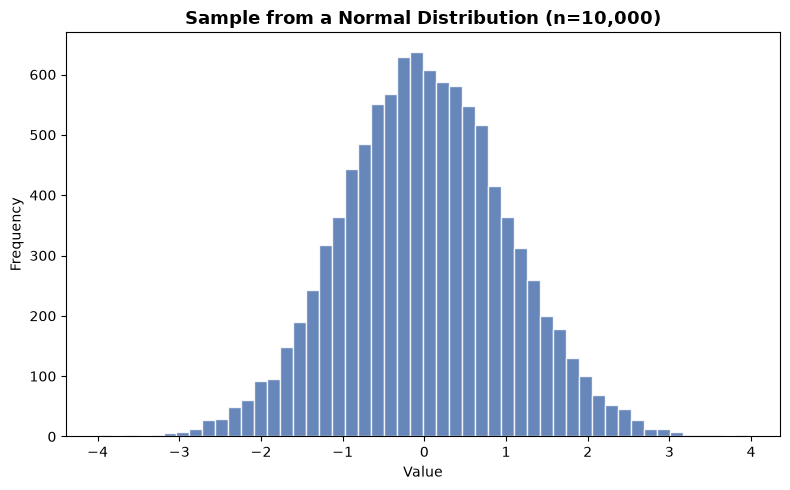

In [13]:
samples = np.random.normal(loc=0, scale=1, size=10000)

plt.figure(figsize=(8, 5))
plt.hist(samples, bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
plt.title("Sample from a Normal Distribution (n=10,000)", fontsize=13, fontweight="bold")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


**What this shows:** *(fill in — does the shape look like a bell curve as expected? Where is it
centered?)*

### 🧪 Hands-On: Binomial Distribution


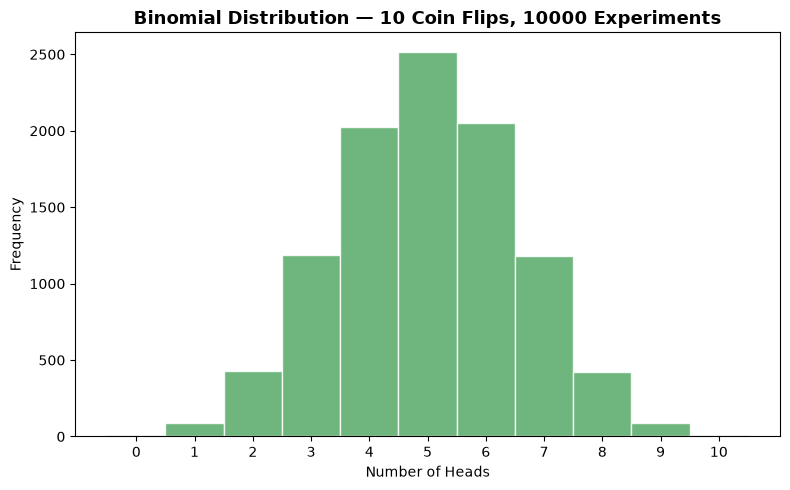

In [14]:
n_trials = 10
n_experiments = 10000
binomial_results = np.random.binomial(n=n_trials, p=0.5, size=n_experiments)

plt.figure(figsize=(8, 5))
plt.hist(binomial_results, bins=range(0, n_trials + 2), color="#55A868",
         edgecolor="white", alpha=0.85, align="left")
plt.title(f"Binomial Distribution — {n_trials} Coin Flips, {n_experiments} Experiments",
          fontsize=13, fontweight="bold")
plt.xlabel("Number of Heads")
plt.ylabel("Frequency")
plt.xticks(range(0, n_trials + 1))
plt.tight_layout()
plt.show()

**What this shows:** *(fill in — which number of heads occurred most often? Does that match
what you'd expect from 10 flips of a fair coin?)*

---


## ✅ Step 6 — Key Takeaways



- Simulating 10,000 coin flips confirmed the theoretical probability of 0.5 almost exactly,
  demonstrating a core principle: as the number of trials grows, observed frequencies converge
  toward the true theoretical probability.
- Working through conditional probability with a die-roll example showed how P(A | B) differs
  meaningfully from P(A) alone — restricting the sample space to only outcomes where B is true
  changes the probability of A, sometimes substantially.
- The medical test scenario was the most striking result: even with a 95%-accurate test, a
  positive result only translated to roughly a 16% actual chance of having the disease. This
  demonstrated why the prior probability (how rare the disease is) matters just as much as the
  test's accuracy — a key intuition behind Bayes' Theorem.
- Sampling from a normal distribution produced the expected symmetric bell curve centered at 0,
  while the binomial simulation of 10 coin flips peaked around 5 heads — both confirming that
  theoretical distributions accurately predict real simulated data at scale.
- Together, these exercises show that probability isn't just abstract math — it directly explains
  how ML models express uncertainty and update beliefs (e.g. a classifier's predicted probability,
  or how a spam filter updates its confidence with new evidence).

---

## 📚 Resources

| Resource | Type | Focus |
|---|---|---|
| [Khan Academy — Probability](https://www.khanacademy.org/math/statistics-probability/probability-library) | Course / Video | Core probability rules and conditional probability |

---

## ✍️ Author

**Zayan Shawareb**
BinX Tech — AI & Machine Learning Internship Program
Week 2, Day 2 — Probability & Distributions

---

## 🔗 Next Step

Proceed to **Day 3 — Linear Algebra for ML**